<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/Entangle004.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


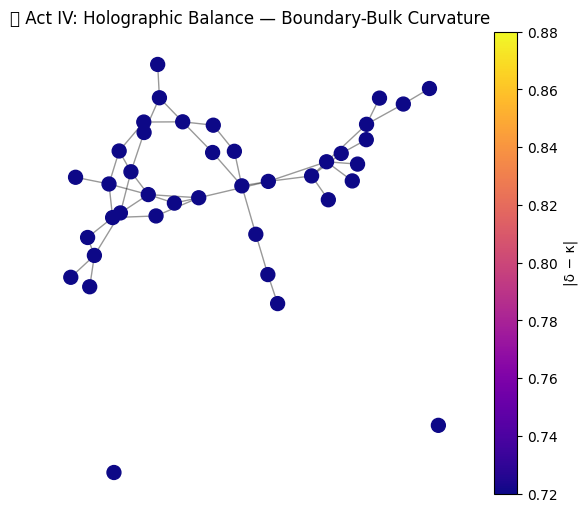

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable

# -------------------------------
# Step 1: Build Bipartite Network
# -------------------------------
def build_boundary_bulk_network(boundary_size=8, bulk_size=32):
    G = nx.Graph()
    boundary_nodes = [f"B{i}" for i in range(boundary_size)]
    bulk_nodes = [f"U{i}" for i in range(bulk_size)]

    G.add_nodes_from(boundary_nodes, region='boundary')
    G.add_nodes_from(bulk_nodes, region='bulk')

    # Connect boundary to bulk randomly
    for b in boundary_nodes:
        connections = np.random.choice(bulk_nodes, size=4, replace=False)
        for u in connections:
            G.add_edge(b, u)

    # Connect bulk internally
    for i in range(bulk_size):
        for j in range(i + 1, bulk_size):
            if np.random.rand() < 0.05:
                G.add_edge(f"U{i}", f"U{j}")

    return G

# -------------------------------
# Step 2: Assign δ and κ by Region
# -------------------------------
def assign_holographic_weights(G, delta_boundary=0.8, kappa_bulk=0.8):
    for node in G.nodes:
        region = G.nodes[node]['region']
        if region == 'boundary':
            G.nodes[node]['delta'] = delta_boundary
            G.nodes[node]['kappa'] = 0.0
        else:
            G.nodes[node]['delta'] = 0.0
            G.nodes[node]['kappa'] = kappa_bulk

# -------------------------------
# Step 3: Compute Curvature
# -------------------------------
def compute_curvature(G):
    curvature = {}
    for node in G.nodes:
        δ = G.nodes[node]['delta']
        κ = G.nodes[node]['kappa']
        curvature[node] = np.abs(δ - κ)
    return curvature

# -------------------------------
# Step 4: Visualize Network
# -------------------------------
def plot_holographic_network(G, curvature):
    pos = nx.spring_layout(G, seed=42)
    node_colors = [curvature[n] for n in G.nodes]

    fig, ax = plt.subplots(figsize=(7, 6))
    nodes = nx.draw_networkx_nodes(G, pos, node_size=100, node_color=node_colors, cmap='plasma', ax=ax)
    nx.draw_networkx_edges(G, pos, alpha=0.4, ax=ax)
    sm = ScalarMappable(cmap='plasma')
    sm.set_array(node_colors)
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label('|δ − κ|')
    ax.set_title("🧠 Act IV: Holographic Balance — Boundary-Bulk Curvature")
    plt.axis('off')
    plt.show()

# -------------------------------
# Step 5: Run Simulation
# -------------------------------
G = build_boundary_bulk_network()
assign_holographic_weights(G)
curvature = compute_curvature(G)
plot_holographic_network(G, curvature)
